# visualization.ipynb

In [1]:
%matplotlib widget

import roadside as rs
import sqlite3
import textwrap
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
from icecream import ic
import numpy as np


In [2]:
# root_dir = "/home/aubrey/Desktop/sam3-2026-01-31"
image_paths = ["example_images/08hs-palms-03-zglw-superJumbo.webp"]
text_prompts=["coconut palm tree"]
db_path = 'test.db'

In [3]:
rs.build_db(db_path, image_paths)

Database test.db created/opened.
SQL script executed successfully.
Changes committed.

Database connection closed.
Ultralytics 8.4.33 🚀 Python-3.13.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 15982MiB)

image 1/1 /home/aubrey/Desktop/temp/example_images/08hs-palms-03-zglw-superJumbo.webp: 1932x1932 2 coconut palm trees, 1318.4ms
Speed: 12.2ms preprocess, 1318.4ms inference, 17.4ms postprocess per image at shape (1, 3, 1932, 1932)
Results saved to /home/aubrey/Desktop/blog2026/runs/segment/predict90


ic| 'copying results_gpu to results_cpu'
ic| 'deleting results_gpu from GPU and clearing caches'
ic| df_input:                                           image_path  detection_id  \
              0  example_images/08hs-palms-03-zglw-superJumbo.webp             1   
              1  example_images/08hs-palms-03-zglw-superJumbo.webp             2   
              
                                                          poly_wkt  \
              0  POLYGON ((486 679, 486 684, 485 685, 485 688, ...   
              1  POLYGON ((1035 1274, 1035 1276, 1034 1277, 103...   
              
                                               hull_indices_string  
              0  1067 1005 949 939 938 898 729 579 575 573 571 ...  
              1  1006 1004 1003 1001 995 855 670 668 664 654 32...  


In [4]:
def contour2binary_image(image_height, image_width, contour):
    img = np.zeros((image_height, image_width), dtype=np.uint8)
    return cv2.drawContours(img, [contour], -1, (255), thickness=cv2.FILLED)

# plt.close('all')

# Usage example
sql =textwrap.dedent("""
    select images.image_id, image_height, image_width, poly_wkt
    from images, detections
    where images.image_id=detections.image_id 
    limit 1
    """)
df = pd.read_sql(sql, sqlite3.connect(db_path))
for _, row in df.iterrows():
    img = contour2binary_image(
        image_height=row.image_height, 
        image_width=row.image_width, 
        contour=rs.wkt2contour(row.poly_wkt))

In [5]:
ic(df)
ic(img);

ic| df:    image_id  image_height  image_width  \
        0         1          2048         1366   
        
                                                    poly_wkt  
        0  POLYGON ((486 679, 486 684, 485 685, 485 688, ...  
ic| img: array([[0, 0, 0, ..., 0, 0, 0],
                [0, 0, 0, ..., 0, 0, 0],
                [0, 0, 0, ..., 0, 0, 0],
                ...,
                [0, 0, 0, ..., 0, 0, 0],
                [0, 0, 0, ..., 0, 0, 0],
                [0, 0, 0, ..., 0, 0, 0]], shape=(2048, 1366), dtype=uint8)


In [6]:
mask = img.copy()

# row_sums is the number of white pixels (value=1) in each row of the mask
# row_indices is 0 ... n spanning the number of rows in the image
row_sums = np.sum(mask, axis=1)
row_indices = np.arange(mask.shape[0])

# # Create the figure with two subplots side-by-side
# # gridspec_kw allows us to control the width ratio of the image vs the plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
#     gridspec_kw={'width_ratios': [3, 1]})

# # Plot the original binary mask
# ax1.imshow(mask, cmap='gray')
# ax1.set_title("Binary Mask of Coconut Palm")
# ax1.set_ylabel("Row Index")
# ax1.set_xlabel("Column Index")
# ax1.yaxis.set_inverted(True)

# # Plot the row sums
# # We plot (row_sums) on X and (row_indices) on Y to align with the image
# ax2.plot(row_sums, row_indices)
# ax2.set_title("Row Sums")
# ax2.set_xlabel("Sum Value (pixels)")
# ax2.grid(True)

# plt.tight_layout()
# plt.show()

In [7]:
ic(row_sums[-20:])

ic| row_sums[-20:]: array([13515, 13260, 13260, 13260, 13515, 13515, 13260, 13260, 13260, 13260, 13260, 13260, 13005, 13005, 13005, 13005, 12750, 12240, 11475, 11475], dtype=uint64)


array([13515, 13260, 13260, 13260, 13515, 13515, 13260, 13260, 13260, 13260, 13260, 13260, 13005, 13005, 13005, 13005, 12750, 12240, 11475, 11475], dtype=uint64)

In [8]:
ic(row_sums)

ic| row_sums: array([    0,     0,     0, ..., 12240, 11475, 11475], shape=(2048,), dtype=uint64)


array([    0,     0,     0, ..., 12240, 11475, 11475], shape=(2048,), dtype=uint64)

In [9]:
def smooth_data(data, window_size):
    # Create a uniform window (kernel)
    window = np.ones(window_size) / window_size
    # Convolve the data with the window
    return np.convolve(data, window, mode='same')

def gaussian_smooth(data, window_size):
    window = np.hanning(window_size) # Bell-shaped curve
    window /= window.sum()           # Normalize
    return np.convolve(data, window, mode='same')

# normalized_row_sum is the proportion of mask pixels in each row
total_row_sums = np.sum(row_sums, dtype=np.float64)
ic(total_row_sums)
normalized_row_sums = row_sums / total_row_sums
ic(normalized_row_sums)
ic(type(normalized_row_sums))
ic(np.sum(normalized_row_sums))  # Should be close to 1.0

# Calculate the difference between consecutive row sums to find where the sum changes significantly
# to_begin=0 to keep the same length as row_sums
differences = np.ediff1d(normalized_row_sums, to_begin=0) 
gaussian_smoothed_differences = gaussian_smooth(differences, window_size=9)
ic(gaussian_smoothed_differences)

# cut_line estimates the y-value which separates the crown from the trunk
# the 10 rows of pixels at the bottom of the mask are ignored when finding cut_line
threshold = -0.00002
stop_search = -10
cut_line = np.max(np.where(gaussian_smoothed_differences[:stop_search] < threshold)).item()

ic| total_row_sums: np.float64(15262260.0)
ic| normalized_row_sums: array([          0,           0,           0, ...,  0.00080198,  0.00075185,  0.00075185], shape=(2048,))
ic| type(normalized_row_sums): <class 'numpy.ndarray'>
ic| np.sum(normalized_row_sums): np.float64(1.0)
ic| gaussian_smoothed_differences: array([          0,           0,           0, ..., -2.2615e-05,  -2.175e-05, -1.5484e-05], shape=(2048,))


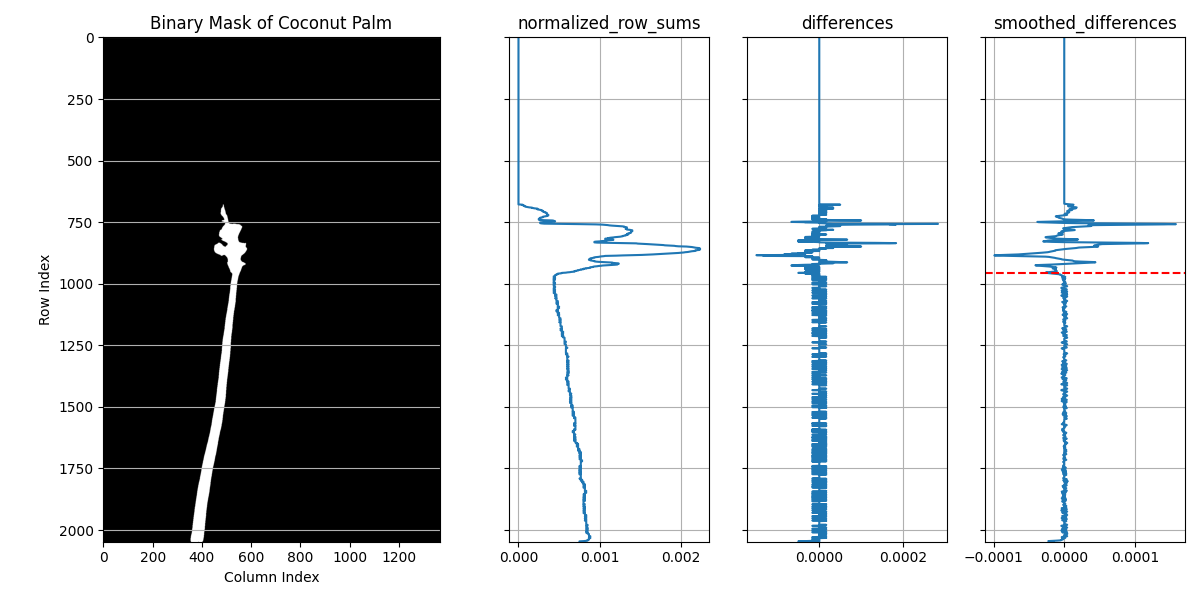

In [23]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [3,1.5,1.5,1.5]})

# Plot the original binary mask
ax1.imshow(mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.yaxis.set_inverted(True)
ax1.xaxis.grid(False)
ax1.yaxis.grid(True)

ax2.plot(normalized_row_sums, row_indices)
ax2.set_title("normalized_row_sums")
ax2.grid(True)

ax3.plot(differences, row_indices)
ax3.set_title("differences")
ax3.grid(True)

ax4.plot(gaussian_smoothed_differences, row_indices)
ax4.set_title("smoothed_differences")
ax4.grid(True)
ax4.axhline(cut_line, color='red', linestyle='--')


plt.tight_layout()
plt.show()

In [11]:
# important: create a copy of mask instead of a view
crown_mask = mask.copy()

# erase mask pixels on rows below (greater than) cut_line
crown_mask[cut_line+1:, :] = 0
ic(crown_mask);


# nonzero_row_indices = np.where(crown_mask.any(axis=1))[0]
# ic(nonzero_row_indices)
# nonzero_col_indices = np.where(crown_mask.any(axis=0))[0]
# ic(nonzero_col_indices)

# ymin = nonzero_row_indices[0].item()
# ymax = nonzero_row_indices[-1].item()

# xmin = nonzero_col_indices[0].item()
# xmax = nonzero_col_indices[-1].item()

ic| crown_mask: array([[0, 0, 0, ..., 0, 0, 0],
                       [0, 0, 0, ..., 0, 0, 0],
                       [0, 0, 0, ..., 0, 0, 0],
                       ...,
                       [0, 0, 0, ..., 0, 0, 0],
                       [0, 0, 0, ..., 0, 0, 0],
                       [0, 0, 0, ..., 0, 0, 0]], shape=(2048, 1366), dtype=uint8)


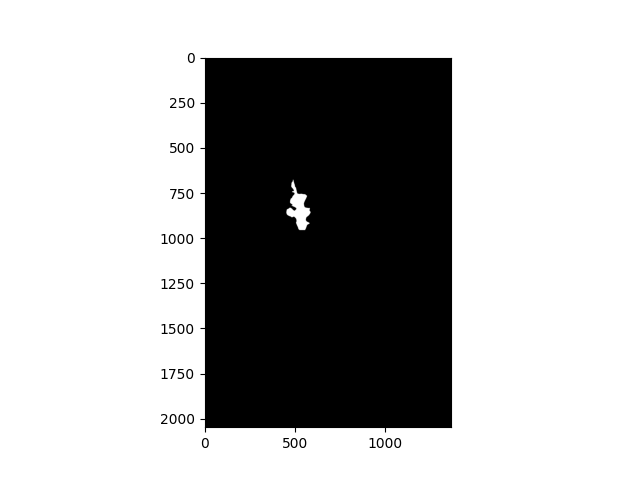

In [12]:
fig, ax1 = plt.subplots(1, 1)
ax1.imshow(crown_mask, cmap='gray')
plt.show()

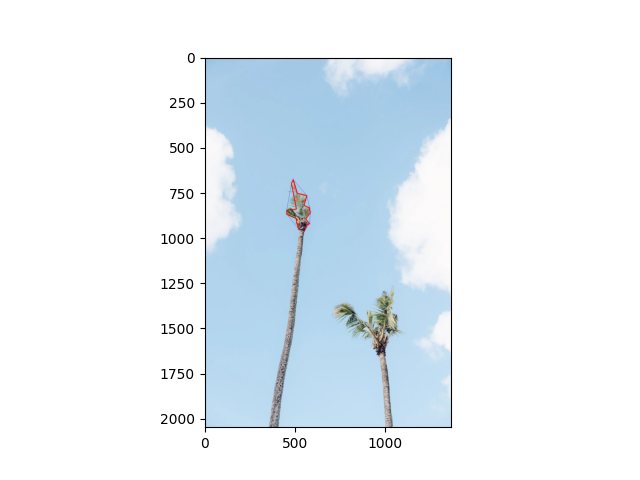

In [13]:
my_img = cv2.imread(image_paths[0])
my_img = cv2.cvtColor(my_img, cv2.COLOR_RGB2BGR)
contours, hierarchy = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    hull = cv2.convexHull(cnt)
    # Draw original contour in green
    cv2.drawContours(my_img, [cnt], 0, (0, 255, 0), 1)
    # Draw convex hull in red
    cv2.drawContours(my_img, [hull], 0, (0, 0, 255), 1)
    
    hull_indices = cv2.convexHull(cnt, returnPoints=False)
    defects = cv2.convexityDefects(cnt, hull_indices)
    
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i,0]
        start = tuple(cnt[s][0])
        end = tuple(cnt[e][0])
        far = tuple(cnt[f][0])
        
        # Optional: Filter by depth to ignore small noise
        if d > 1:
            cv2.line(img=my_img, pt1=start, pt2=far, color=(255, 0, 0), thickness=3)
            cv2.line(img=my_img, pt1=end, pt2=far, color=(255, 0, 0), thickness=3)
            # cv2.circle(img=my_img, center=far, radius=5, color=(0, 0, 255), thickness=-1)
    
fig, ax1 = plt.subplots(1, 1)
ax1.imshow(my_img)
plt.show()


In [14]:
ic(start, end, far)
len(contours)

ic| start: (np.int32(563), np.int32(767))
    end: (np.int32(488), np.int32(679))
    far: (np.int32(510), np.int32(754))


1

NameError: name 'ymin' is not defined

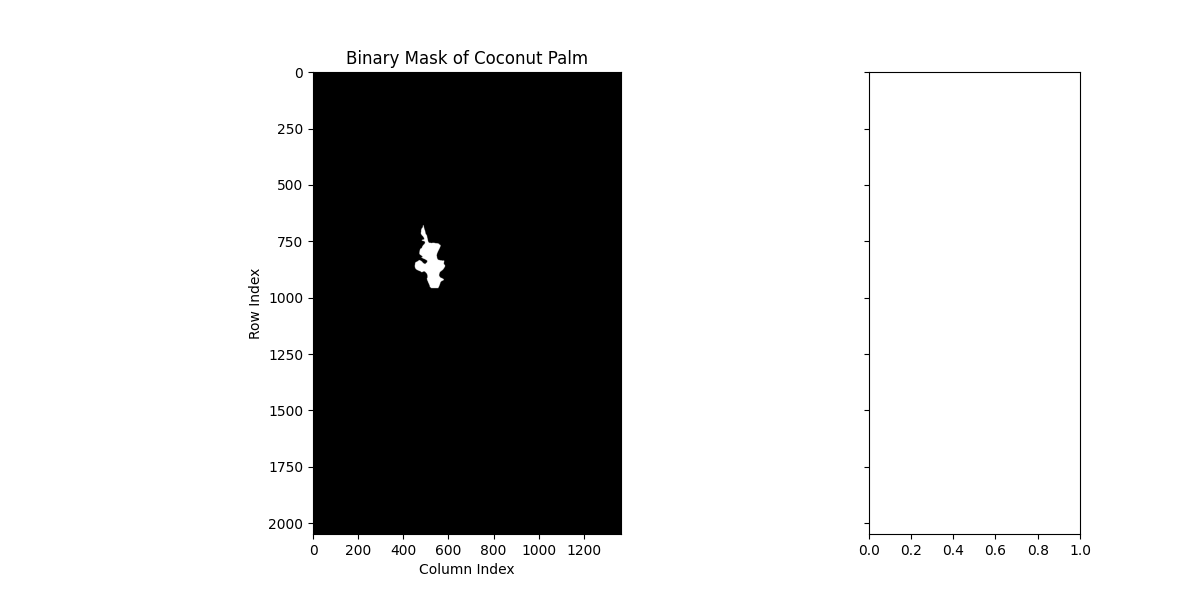

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
    gridspec_kw={'width_ratios': [3, 1]})

# Plot the original binary mask
ax1.imshow(crown_mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.set_ylim(ymin, ymax)
ax1.set_xlim(xmin, xmax)
ax1.yaxis.set_inverted(True)


# Plot the row sums
# We plot (row_sums) on X and (row_indices) on Y to align with the image
# ax2.plot(row_sums, row_indices)
# ax2.set_title("Row Sums")
# ax2.set_xlabel("Sum Value (pixels)")
# ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

# 1. Load and process image
img = cv2.imread('shape.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)

# 2. Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# 3. Calculate and draw hull for each contour
for cnt in contours:
    hull = cv2.convexHull(cnt)
    # Draw original contour in green
    cv2.drawContours(img, [cnt], 0, (0, 255, 0), 2)
    # Draw convex hull in red
    cv2.drawContours(img, [hull], 0, (0, 0, 255), 3)

cv2.imshow('Convex Hull', img)
cv2.waitKey(0)


In [ ]:
nonzero_row_indices = np.where(crown_mask.any(axis=1))[0]
ic(nonzero_row_indices)
nonzero_col_indices = np.where(crown_mask.any(axis=0))[0]
ic(nonzero_col_indices)

ymin = nonzero_row_indices[0].item()
ymax = nonzero_row_indices[-1].item()

xmin = nonzero_col_indices[0].item()
xmax = nonzero_col_indices[-1].item()

In [ ]:
# import cv2
# import numpy as np

# # Load and binarize image
# img = cv2.imread('image.png')
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# ret, thresh = cv2.threshold(gray, 127, 255, 0)

# Find contours
# contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours, _ = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    # Calculate convex hull
    hull = cv2.convexHull(cnt)
    
    # Draw original contour (green) and hull (red)
    cv2.drawContours(img, [cnt], 0, (0, 255, 0), 2)
    cv2.drawContours(img, [hull], 0, (0, 0, 255), 3)

cv2.imshow('Convex Hull', img)
cv2.waitKey(0)


In [ ]:
# Plot the original binary mask
ax1.imshow(crown_mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.yaxis.set_inverted(True)


In [ ]:
ic(type(row_sums))  
delta = np.diff(row_sums.astype(np.int32))
ic(type(delta))
plt.plot(delta
plt.title("Difference of Row Sums")
plt.xlabel("Row Index")
plt.ylabel("Difference in Sum Value")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Causes huge numbers
a = np.array([5, 10, 2, 8], dtype=np.uint8)
print(np.diff(a)) 
# Output: [  5 246   6] (10-2 is 8, but 2-10 wraps)

# Correct approach
b = a.astype(np.int16)
print(np.diff(b)) 
# Output: [ 5 -8  6]


In [ ]:
diff